In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from collections import Counter
from itertools import combinations
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
# Load data
df = pd.read_csv("train.csv")

In [3]:
df["capturedAt"] = pd.to_datetime(df["capturedAt"])

In [4]:
date_counts = (
    df["capturedAt"]
    .dt.date
    .value_counts()
    .sort_index()
)
date_counts.index.min(), date_counts.index.max()

(datetime.date(2025, 1, 1), datetime.date(2025, 3, 22))

In [5]:
start_date = date_counts.index.min()
end_date = date_counts.index.max()
num_days = (end_date - start_date).days + 1
num_days

81

In [6]:
all_dates = pd.date_range(start_date, end_date, freq="D").date
missing_dates = sorted(set(all_dates) - set(date_counts.index))
missing_dates

[datetime.date(2025, 1, 4),
 datetime.date(2025, 1, 9),
 datetime.date(2025, 1, 12),
 datetime.date(2025, 1, 13),
 datetime.date(2025, 1, 14),
 datetime.date(2025, 1, 15),
 datetime.date(2025, 1, 16),
 datetime.date(2025, 1, 17),
 datetime.date(2025, 1, 18),
 datetime.date(2025, 1, 19),
 datetime.date(2025, 1, 20),
 datetime.date(2025, 1, 21),
 datetime.date(2025, 1, 22),
 datetime.date(2025, 1, 23),
 datetime.date(2025, 1, 24),
 datetime.date(2025, 1, 25),
 datetime.date(2025, 1, 26),
 datetime.date(2025, 1, 27),
 datetime.date(2025, 1, 28),
 datetime.date(2025, 1, 29),
 datetime.date(2025, 1, 30),
 datetime.date(2025, 1, 31)]

In [7]:
len(missing_dates)

22

In [8]:
def plot_daily_counts(
    date_counts,
    title="Rows per Date",
    figsize=(16, 4),
    marker="o",
    markersize=3,
    grid=True,
):
    full_dates = pd.date_range(
        start=date_counts.index.min(),
        end=date_counts.index.max(),
        freq="D",
    )

    date_counts_full = date_counts.reindex(full_dates, fill_value=0)

    plt.figure(figsize=figsize)
    plt.plot(
        date_counts_full.index,
        date_counts_full.values,
        marker=marker,
        markersize=markersize,
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Count")

    if grid:
        plt.grid(True)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

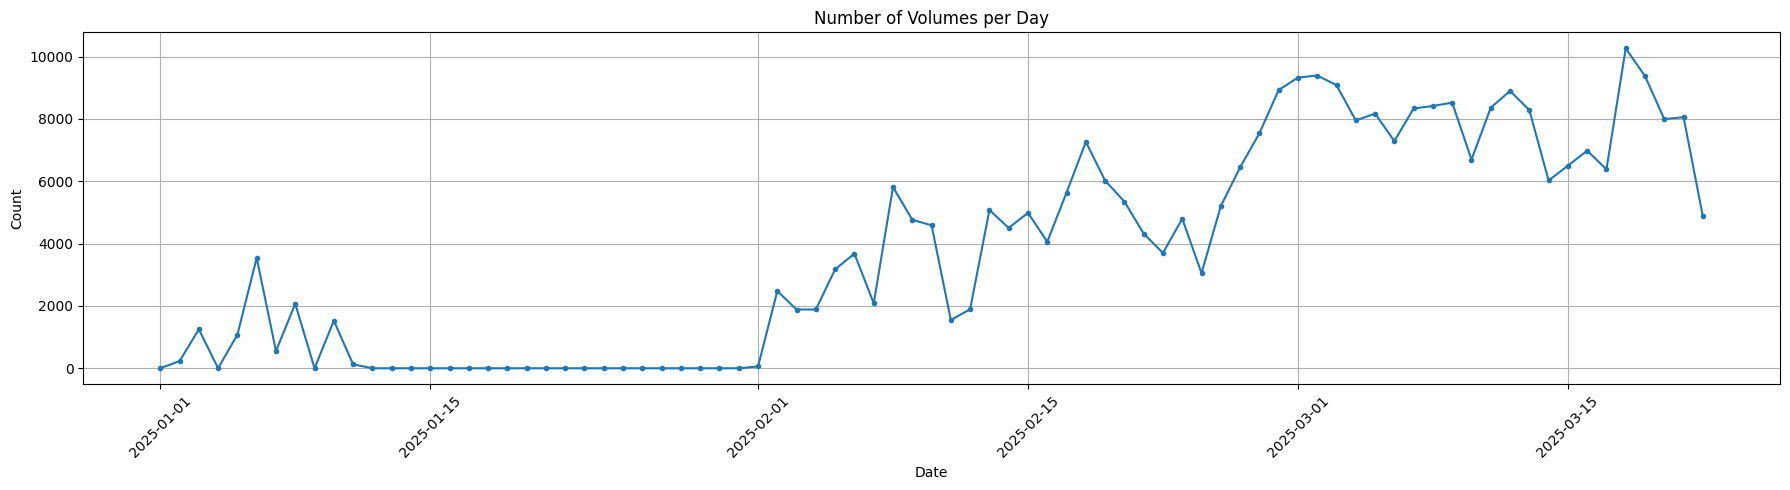

In [9]:
plot_daily_counts(
    date_counts,
    title="Number of Volumes per Day",
    figsize=(18, 5),
)